## Walk-forward LLM оптимизация портфеля

Ноутбук запускает сравнительный walk-forward эксперимент по нескольким LLM-моделям. На каждом проходе модель выбирает портфель только по train-окну, а результат проверяется на следующем test-окне.

Тяжелая логика эксперимента, агрегации эпох и построения графиков вынесена в `trading_optimizer.portfolio_return_optimizer`, чтобы ноутбук оставался коротким сценарием запуска.


In [14]:
from pathlib import Path
import importlib
import os
import sys

import pandas as pd

ROOT = Path.cwd()
CODE_DIR = ROOT / "notebook_code" if (ROOT / "notebook_code").exists() else ROOT
DATA_DIR = CODE_DIR / "data"
PROJECT_DIR = CODE_DIR / "trading_optimizer"
SRC_DIR = PROJECT_DIR / "src"
sys.path.insert(0, str(CODE_DIR))
sys.path.insert(0, str(SRC_DIR))

import trading_optimizer.portfolio_return_optimizer as portfolio_return_optimizer
importlib.reload(portfolio_return_optimizer)

from llm_config import configure_llm_environment, get_return_risk_models
from trading_optimizer.portfolio_return_optimizer import (
    plot_walk_forward_comparison,
    run_multi_model_walk_forward_llm,
)

print("Notebook code:", CODE_DIR)
print("Data dir:", DATA_DIR)
print("Project src:", SRC_DIR)


Notebook code: c:\Users\Jet\Desktop\ya\notebook_code
Data dir: c:\Users\Jet\Desktop\ya\notebook_code\data
Project src: c:\Users\Jet\Desktop\ya\notebook_code\trading_optimizer\src


In [15]:
SEED = 42
LLM_TEMPERATURE = 1.0
configure_llm_environment(CODE_DIR / ".env")

print("OpenAI/RouterAI model:", os.environ.get("OPENAI_MODEL"))
print("OpenAI/RouterAI base URL:", os.environ.get("OPENAI_BASE_URL"))
print("OpenAI/RouterAI API key set:", bool(os.environ.get("OPENAI_API_KEY")))
print("GigaChat auth set:", bool(os.environ.get("GIGACHAT_CREDENTIALS") or os.environ.get("GIGACHAT_ACCESS_TOKEN")))

OpenAI/RouterAI model: openai/gpt-oss-20b
OpenAI/RouterAI base URL: https://routerai.ru/api/v1
OpenAI/RouterAI API key set: True
GigaChat auth set: False


In [ ]:
MAX_SIGMA_ANN = 0.35

WF_DATA_PATH = DATA_DIR / "raw_dataset.parquet"
WF_OUT_DIR = CODE_DIR / "experiments_walk_forward_llm"
WF_OUT_DIR.mkdir(parents=True, exist_ok=True)

WF_TRAIN_WINDOW = 504
WF_TEST_WINDOW = 21
WF_STEP = 21
WF_START_STEP = -1  
WF_MAX_STEPS = 1
WF_MIN_ASSETS = 3
WF_MAX_ASSETS = 10
WF_ROLLING_WINDOW = 21
WF_TRADING_DAYS = 252
WF_INITIAL_RANDOM_SAMPLES = 10
WF_LLM_ITERATIONS = 50
WF_CANDIDATES = 3
WF_LLM_ATTEMPTS = 1
WF_OPTIMIZER_VERBOSE = True
WF_MODELS = get_return_risk_models()

prices_walk_forward = pd.read_parquet(WF_DATA_PATH)

print("Walk-forward data:", prices_walk_forward.shape, WF_DATA_PATH)
print("Output dir:", WF_OUT_DIR)
print("Models:", WF_MODELS)
print("Train/test/step/start/max_steps:", WF_TRAIN_WINDOW, WF_TEST_WINDOW, WF_STEP, WF_START_STEP, WF_MAX_STEPS)
print("LLM iterations/candidates/attempts:", WF_LLM_ITERATIONS, WF_CANDIDATES, WF_LLM_ATTEMPTS)
print("Inner LLM optimizer verbose:", WF_OPTIMIZER_VERBOSE)

Walk-forward data: (2613, 86) c:\Users\Jet\Desktop\ya\notebook_code\data\raw_dataset.parquet
Output dir: c:\Users\Jet\Desktop\ya\notebook_code\experiments_walk_forward_llm
Models: ['openai/gpt-oss-20b', 'deepseek/deepseek-v4-pro']
Train/test/step/start/max_steps: 504 21 21 -1 1
LLM iterations/candidates/attempts: 20 3 1
Inner LLM optimizer verbose: True


In [ ]:
walk_forward_results_all, walk_forward_equity_curve_all, walk_forward_summary_all, walk_forward_epoch_scores_all = run_multi_model_walk_forward_llm(
    prices=prices_walk_forward,
    models=WF_MODELS,
    out_dir=WF_OUT_DIR,
    train_window=WF_TRAIN_WINDOW,
    test_window=WF_TEST_WINDOW,
    step=WF_STEP,
    min_assets=WF_MIN_ASSETS,
    max_assets=WF_MAX_ASSETS,
    max_sigma_ann=MAX_SIGMA_ANN,
    rolling_window=WF_ROLLING_WINDOW,
    trading_days=WF_TRADING_DAYS,
    initial_random_samples=WF_INITIAL_RANDOM_SAMPLES,
    iterations=WF_LLM_ITERATIONS,
    candidates_per_iter=WF_CANDIDATES,
    llm_attempts_per_iteration=WF_LLM_ATTEMPTS,
    seed=SEED,
    base_url=os.environ.get("OPENAI_BASE_URL"),
    temperature=LLM_TEMPERATURE,
    verbose=True,
    optimizer_verbose=WF_OPTIMIZER_VERBOSE,
    start_step=WF_START_STEP,
    max_steps=WF_MAX_STEPS,
)

print("Сводка по моделям:")
display(walk_forward_summary_all)
print("Сохранено в:", WF_OUT_DIR)
display(walk_forward_results_all)


In [20]:
walk_forward_results_all = pd.read_csv(WF_OUT_DIR / "all_models_walk_forward_results.csv")
walk_forward_equity_curve_all = pd.read_csv(WF_OUT_DIR / "all_models_walk_forward_equity_curve.csv")
walk_forward_summary_all = pd.read_csv(WF_OUT_DIR / "all_models_walk_forward_summary.csv")
walk_forward_epoch_scores_all = pd.read_csv(WF_OUT_DIR / "all_models_walk_forward_epoch_scores.csv")

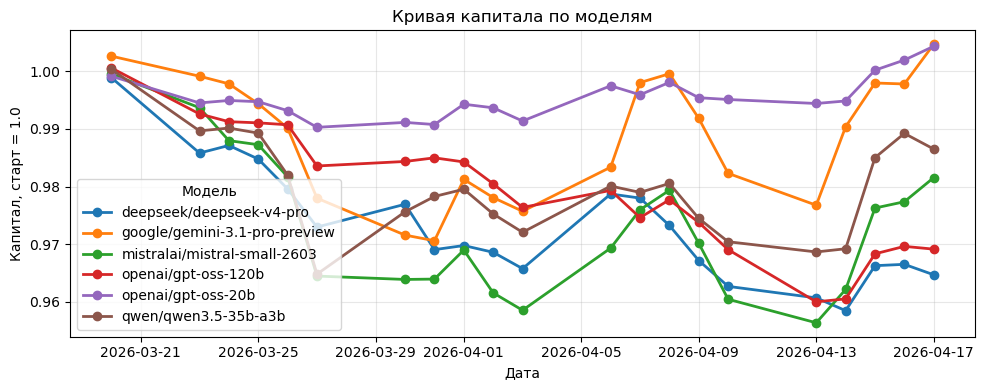

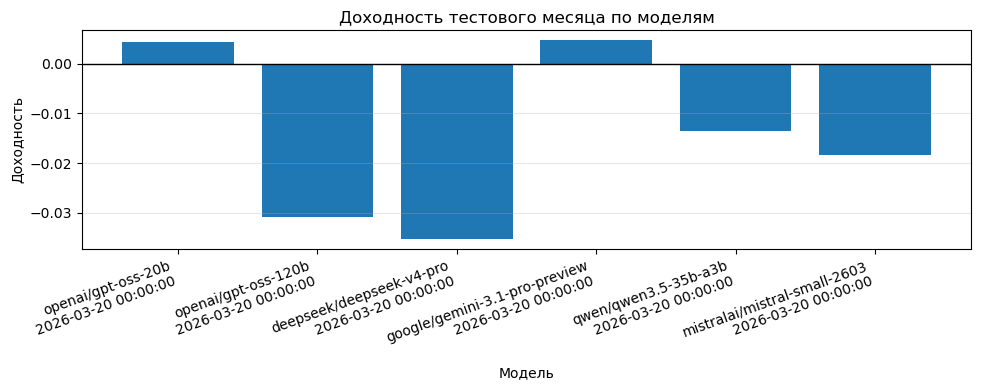

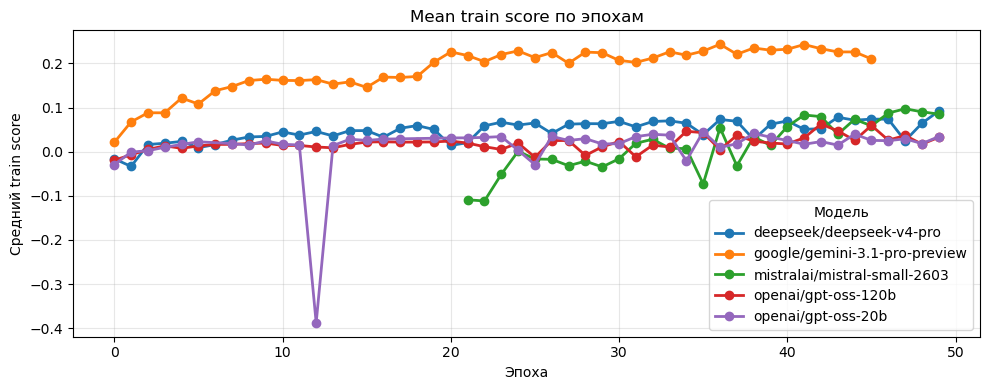

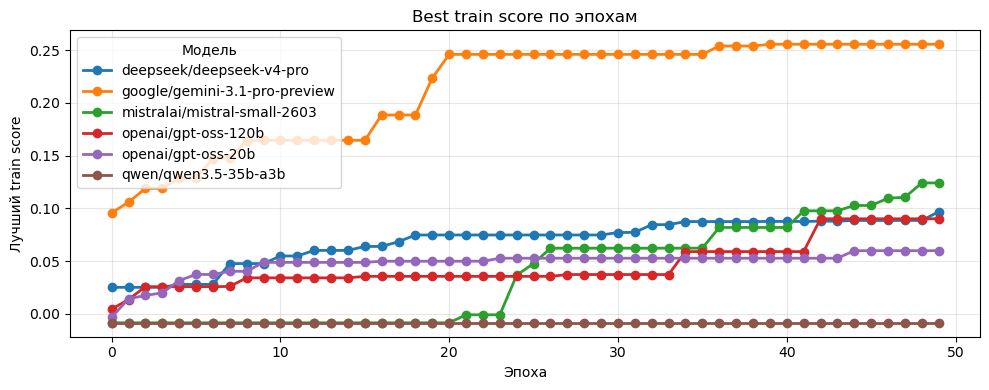

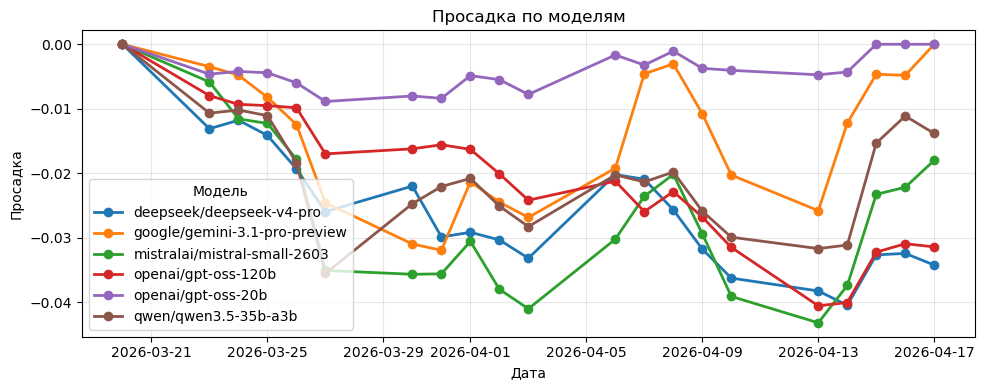

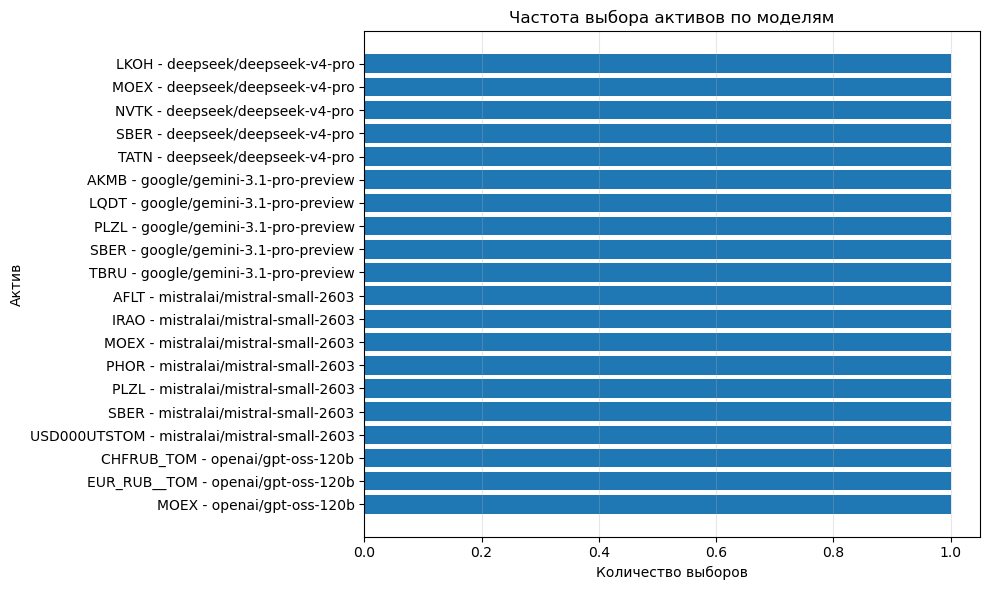

In [21]:
asset_frequency = plot_walk_forward_comparison(
    results_all=walk_forward_results_all,
    equity_curve_all=walk_forward_equity_curve_all,
    epoch_scores_all=walk_forward_epoch_scores_all,
    out_dir=WF_OUT_DIR,
    show=True,
)

## Формула score

Текущая целевая функция остается прежней:

`score = mu_ann - 20 * risk_violation - 0.02 * concentration`

где `mu_ann` — ожидаемая годовая доходность на train-окне, `risk_violation` — превышение rolling-риска `sigma_q_0.9` над лимитом `MAX_SIGMA_ANN`, а `concentration` штрафует слишком концентрированные веса.


## Аналитика выбора активов по моделям

Этот блок показывает, какие активы выбрала каждая модель, где был консенсус между моделями и какие активы помогали или тянули вниз на test-окне.


## Краткое обоснование

- SBER выбрали все модели: это главный консенсус по ликвидной российской бумаге.
- Gemini показал лучший test return: смесь PLZL, LQDT, AKMB, SBER, TBRU дала баланс доходности и защитных активов.
- DeepSeek и GPT-OSS-120B проиграли на test: часть выбранных ими активов сильно просела на невидимом окне.
- Qwen по истории имеет мало LLM-кандидатов; закончились деньги) .


Отчет: c:\Users\Jet\Desktop\ya\notebook_code\experiments_walk_forward_llm\model_asset_analysis.md


# Аналитика выбора акций по моделям

Модели выбирали портфели на train-окне, а проверка идет на невидимом test-окне.

- Train: 2024-03-27 - 2026-03-19
- Test: 2026-03-20 - 2026-04-17

Важно: это один test-месяц, не инвестиционная рекомендация.

## Итог по моделям

| Модель | Test return | Train score | Train risk q0.9 | Активов | Финальный портфель |
|---|---:|---:|---:|---:|---|
| google/gemini-3.1-pro-preview | 0.47% | 0.2555 | 18.48% | 5 | PLZL 39%, LQDT 20%, AKMB 18%, SBER 13%, TBRU 10% |
| openai/gpt-oss-20b | 0.43% | 0.0598 | 15.07% | 3 | SBER 45%, FXIT 30%, FXUS 25% |
| qwen/qwen3.5-35b-a3b | -1.35% | -0.0085 | 26.13% | 5 | IRAO 38%, SBER 25%, MOEX 21%, USD000UTSTOM 9%, MGNT 7% |
| mistralai/mistral-small-2603 | -1.85% | 0.1241 | 29.41% | 7 | SBER 25%, MOEX 20%, PLZL 15%, AFLT 15%, PHOR 10%, IRAO 10%, USD000UTSTOM 5% |
| openai/gpt-oss-120b | -3.09% | 0.0901 | 22.42% | 6 | MOEX 17%, SPBE 17%, EUR_RUB__TOM 17%, USD000UTSTOM 17%, CHFRUB_TOM 17%, SBER 17% |
| deepseek/deepseek-v4-pro | -3.53% | 0.0967 | 33.32% | 5 | SBER 65%, LKOH 15%, NVTK 12%, MOEX 4%, TATN 4% |

## Консенсус по активам

| Актив | Сколько моделей выбрали | Суммарный вес | Test доходность актива | Модели |
|---|---:|---:|---:|---|
| SBER | 6 | 189.7% | 1.16% | Все модели |
| MOEX | 4 | 61.9% | -1.82% | DeepSeek, Mistral, GPT-OSS-120B, Qwen |
| USD000UTSTOM | 3 | 30.4% | -8.19% | Mistral, GPT-OSS-120B, Qwen |
| PLZL | 2 | 54.0% | -1.43% | Gemini, Mistral |
| IRAO | 2 | 48.2% | 0.82% | Mistral, Qwen |

## Краткое обоснование

- SBER выбрали все модели: это главный консенсус по ликвидной российской бумаге.
- Gemini показал лучший test return: смесь PLZL, LQDT, AKMB, SBER, TBRU дала баланс доходности и защитных активов.
- DeepSeek и GPT-OSS-120B проиграли на test: часть выбранных ими активов сильно просела на невидимом окне.
- Qwen по истории имеет мало LLM-кандидатов; его итог нужно трактовать осторожно.

## Как читать

- `Train score` объясняет, почему оптимизатор выбрал портфель на обучающем окне.
- `Test return` показывает реальную проверку на невидимом периоде.
- Консенсус по тикерам полезен как сигнал, но не гарантирует будущую доходность.

## Файлы

- `model_final_asset_weights.csv`
- `asset_consensus_summary.csv`
- `model_asset_history_frequency.csv`


Финальные веса активов по моделям


,model,asset,weight,asset_train_return,asset_test_return,weighted_test_contribution_approx,model_test_return,selected_by_models
0,deepseek/deepseek-v4-pro,SBER,0.650000,0.345680,0.011588,0.007532,-0.035319,6
1,deepseek/deepseek-v4-pro,LKOH,0.150000,-0.035873,-0.085931,-0.012890,-0.035319,1
2,deepseek/deepseek-v4-pro,NVTK,0.120000,0.163793,-0.169943,-0.020393,-0.035319,1
3,deepseek/deepseek-v4-pro,MOEX,0.040000,-0.023252,-0.018223,-0.000729,-0.035319,4
4,deepseek/deepseek-v4-pro,TATN,0.040000,0.183166,-0.134513,-0.005381,-0.035319,1
5,google/gemini-3.1-pro-preview,PLZL,0.390000,1.254912,-0.014286,-0.005571,0.004690,2
6,google/gemini-3.1-pro-preview,LQDT,0.200000,0.421979,0.011130,0.002226,0.004690,1
7,google/gemini-3.1-pro-preview,AKMB,0.180000,0.403216,0.013195,0.002375,0.004690,1
8,google/gemini-3.1-pro-preview,SBER,0.130000,0.345680,0.011588,0.001506,0.004690,6
9,google/gemini-3.1-pro-preview,TBRU,0.100000,0.388985,0.016089,0.001609,0.004690,1


Консенсус активов между моделями


,asset,selected_by_models,total_final_weight,avg_final_weight,avg_asset_train_return,avg_asset_test_return,avg_weighted_test_contribution,models
0,SBER,6,1.896648,0.316108,0.345680,0.011588,0.003663,"deepseek/deepseek-v4-pro, google/gemini-3.1-pr..."
1,MOEX,4,0.619257,0.154814,-0.023252,-0.018223,-0.002821,"deepseek/deepseek-v4-pro, mistralai/mistral-sm..."
2,USD000UTSTOM,3,0.304461,0.101487,-0.081307,-0.081887,-0.008310,"mistralai/mistral-small-2603, openai/gpt-oss-1..."
3,PLZL,2,0.540000,0.270000,1.254912,-0.014286,-0.003857,"google/gemini-3.1-pro-preview, mistralai/mistr..."
4,IRAO,2,0.482373,0.241187,-0.055070,0.008203,0.001978,"mistralai/mistral-small-2603, qwen/qwen3.5-35b..."
5,FXIT,1,0.300000,0.300000,NaN,NaN,NaN,openai/gpt-oss-20b
6,FXUS,1,0.250000,0.250000,NaN,NaN,NaN,openai/gpt-oss-20b
7,LQDT,1,0.200000,0.200000,0.421979,0.011130,0.002226,google/gemini-3.1-pro-preview
8,AKMB,1,0.180000,0.180000,0.403216,0.013195,0.002375,google/gemini-3.1-pro-preview
9,CHFRUB_TOM,1,0.166667,0.166667,NaN,NaN,NaN,openai/gpt-oss-120b


Частота активов в оцененных кандидатах моделей


,model,asset,evaluated_count,llm_count,seed_count,avg_weight_when_present,max_weight_when_present,avg_candidate_score,best_candidate_score,avg_candidate_sigma_q09
0,deepseek/deepseek-v4-pro,SBER,141,139,2,0.284692,0.650000,0.044889,0.096705,0.296421
1,deepseek/deepseek-v4-pro,MOEX,141,138,3,0.100486,0.240000,0.043720,0.096705,0.298292
2,deepseek/deepseek-v4-pro,LKOH,124,124,0,0.184677,0.300000,0.050140,0.096705,0.313592
3,deepseek/deepseek-v4-pro,NVTK,123,122,1,0.167416,0.322192,0.042560,0.096705,0.315938
4,deepseek/deepseek-v4-pro,PHOR,68,67,1,0.058381,0.274929,0.057709,0.087800,0.321642
...,...,...,...,...,...,...,...,...,...,...
75,google/gemini-3.1-pro-preview,TMOS,1,1,0,0.050000,0.050000,0.149129,0.149129,0.048071
76,google/gemini-3.1-pro-preview,MAGN,3,0,3,0.114863,0.215645,-0.859256,-0.137382,0.374839
77,google/gemini-3.1-pro-preview,UNAC,2,0,2,0.429581,0.482335,-0.826758,-0.237764,0.338878
78,google/gemini-3.1-pro-preview,FIVE,2,0,2,0.140719,0.206239,-0.111449,-0.085517,0.216686


График финальных весов


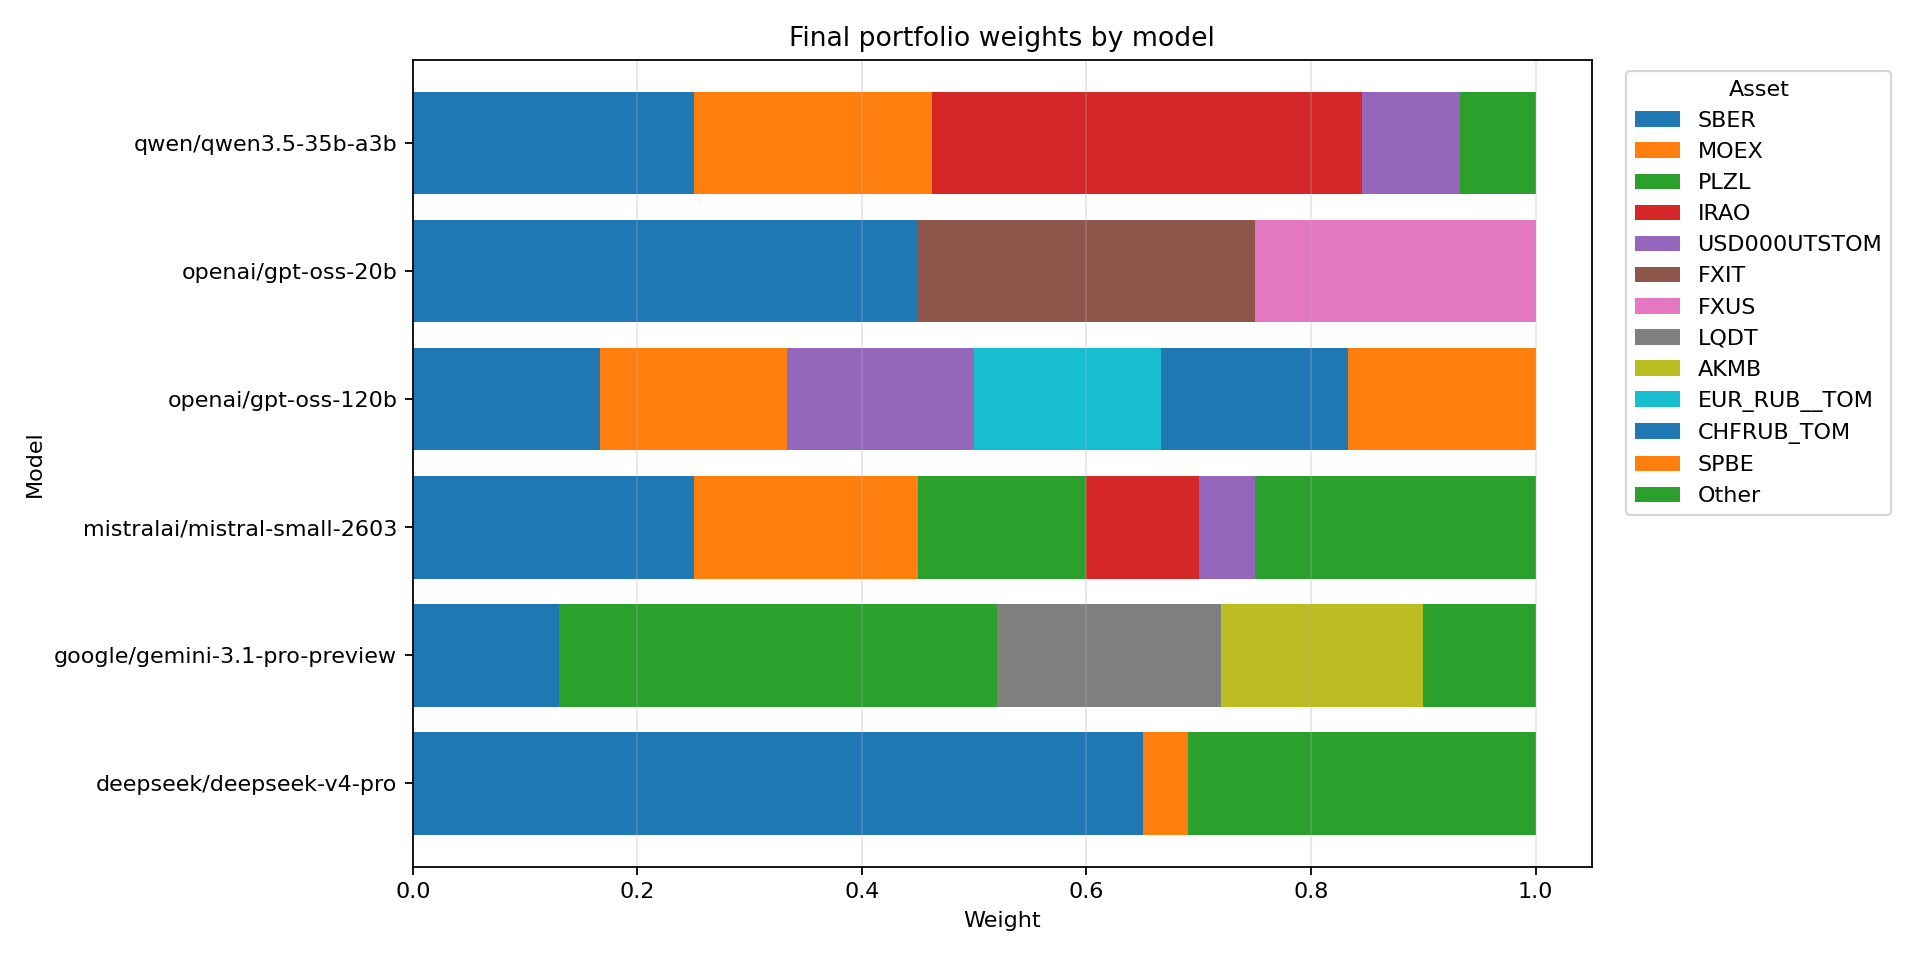

График консенсуса


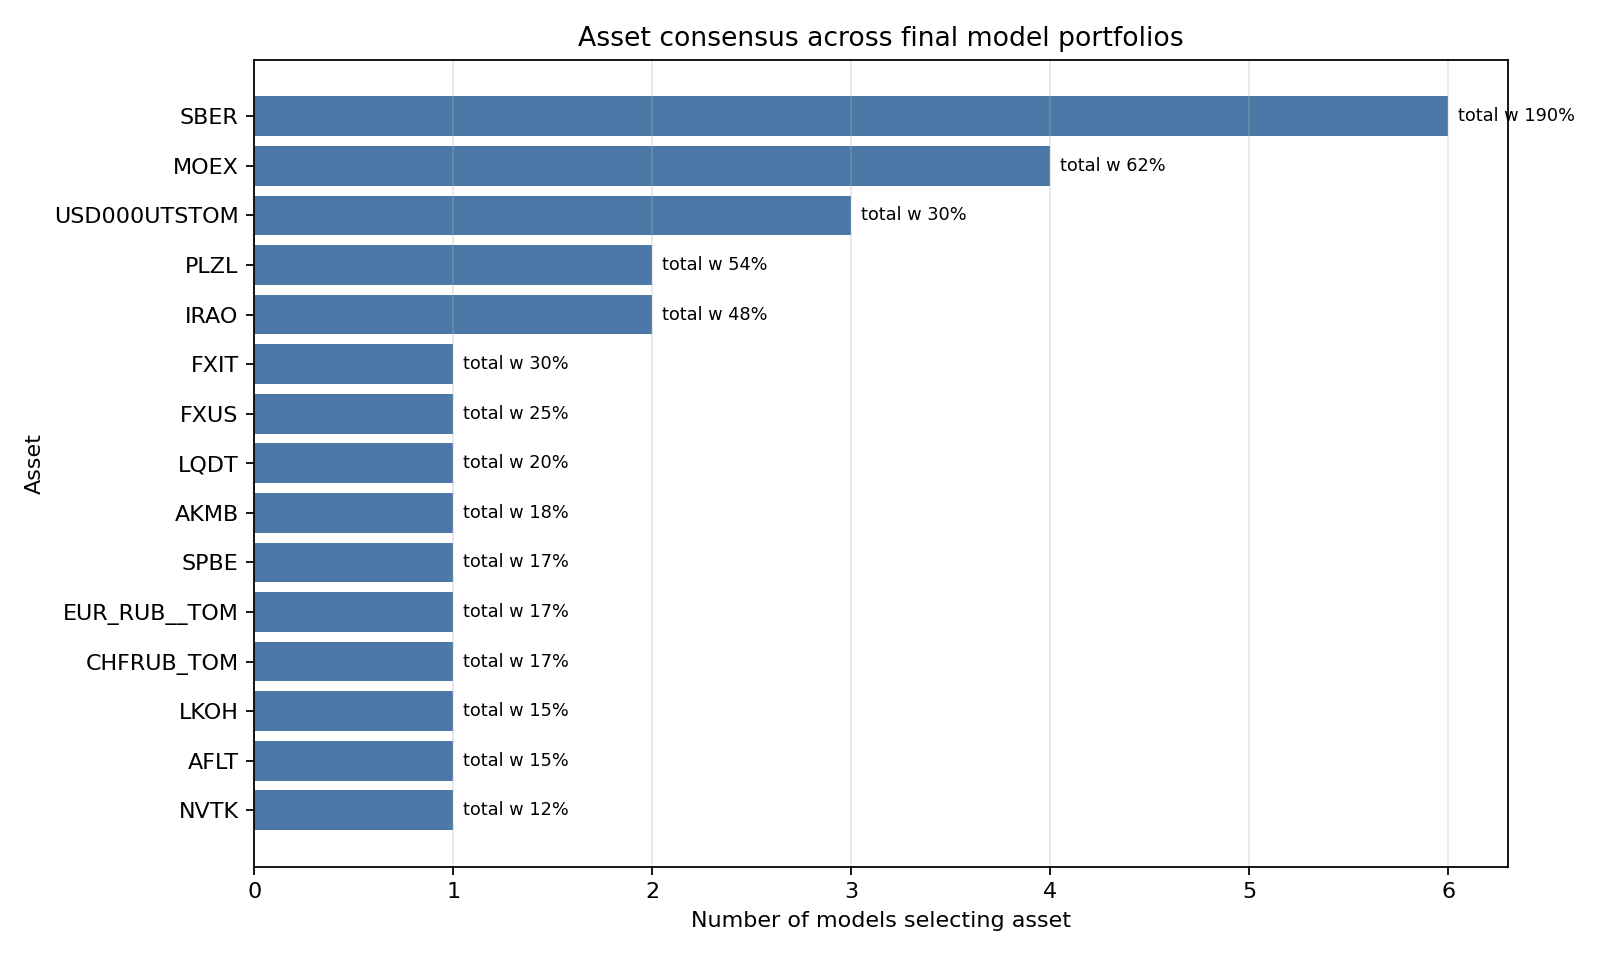

In [23]:
from IPython.display import Markdown, Image, display

ANALYSIS_REPORT_PATH = WF_OUT_DIR / "model_asset_analysis.md"
FINAL_ASSETS_PATH = WF_OUT_DIR / "model_final_asset_weights.csv"
CONSENSUS_PATH = WF_OUT_DIR / "asset_consensus_summary.csv"
HISTORY_FREQ_PATH = WF_OUT_DIR / "model_asset_history_frequency.csv"
WEIGHTS_PNG_PATH = WF_OUT_DIR / "model_final_asset_weights.png"
CONSENSUS_PNG_PATH = WF_OUT_DIR / "asset_consensus_summary.png"

analysis_files = [
    ANALYSIS_REPORT_PATH,
    FINAL_ASSETS_PATH,
    CONSENSUS_PATH,
    HISTORY_FREQ_PATH,
    WEIGHTS_PNG_PATH,
    CONSENSUS_PNG_PATH,
]
missing_analysis_files = [path for path in analysis_files if not path.exists()]
if missing_analysis_files:
    raise FileNotFoundError(
        "Не найдены файлы аналитики. Сначала запусти ячейку/скрипт генерации аналитики: "
        + ", ".join(str(path) for path in missing_analysis_files)
    )

model_final_asset_weights = pd.read_csv(FINAL_ASSETS_PATH)
asset_consensus_summary = pd.read_csv(CONSENSUS_PATH)
model_asset_history_frequency = pd.read_csv(HISTORY_FREQ_PATH)

print("Отчет:", ANALYSIS_REPORT_PATH)
display(Markdown(ANALYSIS_REPORT_PATH.read_text(encoding="utf-8")))

print("Финальные веса активов по моделям")
display(
    model_final_asset_weights.sort_values(["model", "weight"], ascending=[True, False])[
        [
            "model",
            "asset",
            "weight",
            "asset_train_return",
            "asset_test_return",
            "weighted_test_contribution_approx",
            "model_test_return",
            "selected_by_models",
        ]
    ]
)

print("Консенсус активов между моделями")
display(
    asset_consensus_summary.sort_values(
        ["selected_by_models", "total_final_weight"], ascending=[False, False]
    )
)

print("Частота активов в оцененных кандидатах моделей")
display(
    model_asset_history_frequency.sort_values(
        ["model", "llm_count", "evaluated_count"], ascending=[True, False, False]
    ).head(80)
)

print("График финальных весов")
display(Image(filename=str(WEIGHTS_PNG_PATH)))

print("График консенсуса")
display(Image(filename=str(CONSENSUS_PNG_PATH)))
